# 03 — Partidos StatsBomb (WC2022, Copa América, Euro)

**Fuente:** `silver.stg_matches_sb`

StatsBomb provee 220 partidos de alta calidad con métricas avanzadas:
- **WC2022** (Qatar) — 64 partidos
- **Copa América 2024** — 32 partidos  
- **Euro 2020** (jugado en 2021) — 51 partidos
- **Euro 2024** (Alemania) — 51 partidos

**Por qué importa para el Monte Carlo:**
Este dataset conecta a los equipos WC2026 con datos de calidad (xG, passes, etc.).
Cuántos de los 48 equipos tienen datos aquí determina cuántos usarán la
Capa 1 del modelo (xG desde StatsBomb) vs. Capa 2 (lambda histórico).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)

## 1. Carga de datos

In [2]:
df = query("SELECT * FROM silver.stg_matches_sb ORDER BY competition_name, season_name, match_date")
print(f"Shape: {df.shape}")
print("Columnas:", df.columns.tolist())
df.head(3)

Shape: (198, 16)
Columnas: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_week', 'competition_slug', 'competition_name', 'season_name', 'home_team_id_sb', 'home_team_name', 'away_team_id_sb', 'away_team_name', 'stage', 'stadium_name']


,match_id,match_date,kick_off,home_score,away_score,match_status,match_week,competition_slug,competition_name,season_name,home_team_id_sb,home_team_name,away_team_id_sb,away_team_name,stage,stadium_name
0,3939969,2024-06-21,00:00:00.000,2,0,available,1,copa_america_2024,Copa America,2024,779,Argentina,1833,Canada,Group Stage,Mercedes-Benz Stadium
1,3939972,2024-06-22,22:00:00.000,1,2,available,1,copa_america_2024,Copa America,2024,3565,Ecuador,3563,Venezuela,Group Stage,Levi''s Stadium
2,3939970,2024-06-22,00:00:00.000,0,0,available,1,copa_america_2024,Copa America,2024,784,Peru,3562,Chile,Group Stage,AT&T Stadium


## 2. Reporte de nulos

In [9]:
null_report(df)

,nulos,pct,dtype


## 3. Partidos por competición

competition_name season_name  partidos
    Copa America        2024        32
  FIFA World Cup        2022        64
       UEFA Euro        2020        51
       UEFA Euro        2024        51


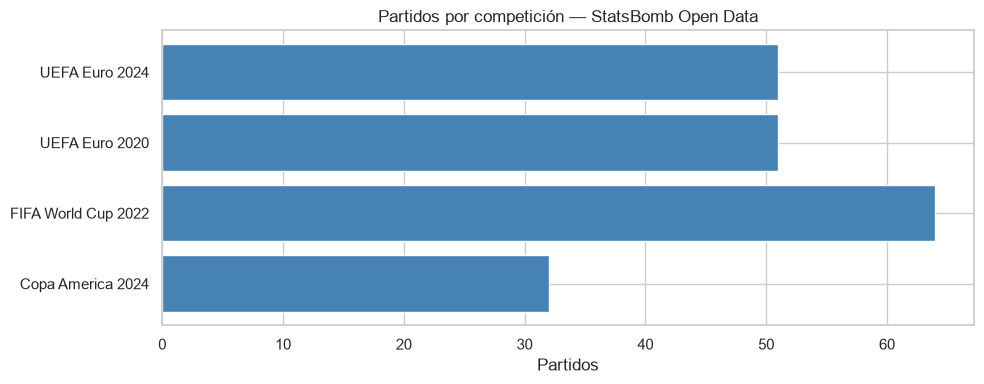

In [4]:
por_competicion = df.groupby(['competition_name', 'season_name']).size().reset_index(name='partidos')
print(por_competicion.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
por_competicion['label'] = por_competicion['competition_name'] + ' ' + por_competicion['season_name'].astype(str)
ax.barh(por_competicion['label'], por_competicion['partidos'], color='steelblue')
ax.set_xlabel('Partidos')
ax.set_title('Partidos por competición — StatsBomb Open Data')
plt.tight_layout()
plt.show()

## 4. Goles por partido por competición

                  mean   std  count
competition_name                   
Copa America      2.19  1.55     32
FIFA World Cup    2.69  1.89     64
UEFA Euro         2.54  1.51    102


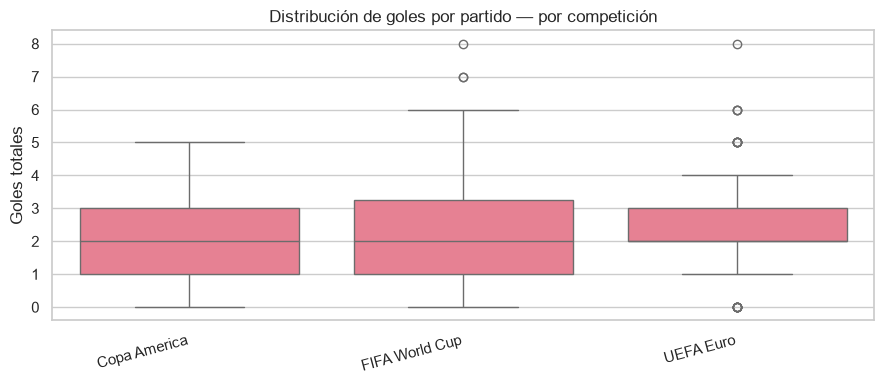

In [5]:
df['total_goals'] = df['home_score'] + df['away_score']

goles_comp = df.groupby('competition_name')['total_goals'].agg(['mean','std','count']).round(2)
print(goles_comp)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x='competition_name', y='total_goals', ax=ax)
ax.set_title('Distribución de goles por partido — por competición')
ax.set_xlabel('')
ax.set_ylabel('Goles totales')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 5. Equipos WC2026 con cobertura StatsBomb

Esta tabla determina qué equipos usan Capa 1 (xG real) vs. Capa 2 (lambda histórico).

In [6]:
dim = query("SELECT canonical_name, confederation FROM gold.dim_teams ORDER BY confederation, canonical_name")

equipos_sb = pd.concat([
    df[['home_team_name']].rename(columns={'home_team_name': 'team'}),
    df[['away_team_name']].rename(columns={'away_team_name': 'team'})
]).drop_duplicates()

dim['en_statsbomb'] = dim['canonical_name'].isin(equipos_sb['team'])

resumen = dim.groupby('confederation')['en_statsbomb'].agg(['sum','count'])
resumen.columns = ['con_datos_sb', 'total_equipos']
resumen['sin_datos_sb'] = resumen['total_equipos'] - resumen['con_datos_sb']
print(resumen)

print(f"\nTotal equipos WC2026 con StatsBomb: {dim['en_statsbomb'].sum()}/{len(dim)}")

print("\nEquipos SIN datos StatsBomb (usarán lambda histórico):")
print(dim[~dim['en_statsbomb']]['canonical_name'].tolist())

               con_datos_sb  total_equipos  sin_datos_sb
confederation                                           
AFC                       6              9             3
CAF                       4             10             6
CONCACAF                  4              6             2
CONMEBOL                  6              6             0
OFC                       0              1             1
UEFA                     14             16             2

Total equipos WC2026 con StatsBomb: 34/48

Equipos SIN datos StatsBomb (usarán lambda histórico):
['Iraq', 'Jordan', 'Uzbekistan', 'Algeria', 'Cape Verde', 'DR Congo', 'Egypt', 'Ivory Coast', 'South Africa', 'Curacao', 'Haiti', 'New Zealand', 'Bosnia and Herzegovina', 'Norway']


## 6. Distribución de resultados por fase

In [7]:
df['result'] = df.apply(
    lambda r: 'home_win' if r.home_score > r.away_score
              else ('away_win' if r.home_score < r.away_score else 'draw'),
    axis=1
)

df['is_group'] = df['stage'].str.contains('Group|group|fase', na=False, case=False)

for fase, label in [(True, 'Fase de grupos'), (False, 'Eliminatorias')]:
    subset = df[df['is_group'] == fase]
    if len(subset) > 0:
        dist = subset['result'].value_counts(normalize=True) * 100
        print(f"\n{label} ({len(subset)} partidos):")
        print(dist.round(1))


Fase de grupos (144 partidos):
result
home_win    37.5
away_win    36.8
draw        25.7
Name: proportion, dtype: float64

Eliminatorias (54 partidos):
result
home_win    48.1
draw        29.6
away_win    22.2
Name: proportion, dtype: float64


## 7. Partidos por equipo WC2026 en StatsBomb

In [8]:
# Contar partidos por equipo para ver quiénes tienen más o menos datos
home_count = df[['home_team_name','total_goals']].rename(columns={'home_team_name':'team','total_goals':'gf'})
away_count = df[['away_team_name','total_goals']].rename(columns={'away_team_name':'team','total_goals':'ga'})

team_counts = pd.concat([
    df['home_team_name'].rename('team'),
    df['away_team_name'].rename('team')
]).value_counts().reset_index(name='partidos_sb')
team_counts.columns = ['team', 'partidos_sb']

# Solo equipos WC2026
wc26_teams = dim['canonical_name'].tolist()
team_counts_wc26 = team_counts[team_counts['team'].isin(wc26_teams)].sort_values('partidos_sb', ascending=False)

print(f"Equipos WC2026 con al menos 1 partido StatsBomb: {len(team_counts_wc26)}")
print(team_counts_wc26.to_string(index=False))

Equipos WC2026 con al menos 1 partido StatsBomb: 34
          team  partidos_sb
       England           19
        France           17
         Spain           17
   Netherlands           15
   Switzerland           14
      Portugal           14
       Croatia           14
     Argentina           13
       Germany           12
       Belgium           12
       Uruguay            9
        Brazil            9
        Canada            9
        Turkey            8
       Austria            8
Czech Republic            8
       Ecuador            7
 United States            7
       Morocco            7
        Mexico            6
      Colombia            6
      Scotland            6
        Panama            4
       Senegal            4
         Japan            4
   South Korea            4
     Australia            4
        Sweden            4
      Paraguay            3
         Qatar            3
       Tunisia            3
          Iran            3
  Saudi Arabia          

## 8. Hallazgos

| Competición | Partidos | Notas |
|-------------|----------|-------|
| WC 2022 (Qatar) | 64 | Completos |
| Copa América 2024 | 32 | Grupos + R16 (sin QF en adelante) |
| Euro 2020 | 51 | Completos |
| Euro 2024 | 51 | Completos |
| **Total** | **198** | |

**Distribución de resultados:**

| Fase | Partidos | Home Win | Draw | Away Win |
|------|----------|----------|------|----------|
| Grupos | 144 | 37.5% | 25.7% | 36.8% |
| Eliminatorias | 54 | 48.1% | 29.6% | 22.2% |

La tasa de empates en grupos (25.7%) es la referencia histórica para calibrar el modelo Monte Carlo.
En eliminatorias sube a 29.6% — los equipos juegan más conservadores buscando llegar a penales.

**Cobertura del modelo:**
- Capa 1 (xG StatsBomb): **34/48** equipos WC2026
- Capa 2 (lambda histórico Kaggle): **14/48** equipos — Iraq, Jordan, Uzbekistan, Algeria, Cape Verde, DR Congo, Egypt, Ivory Coast, South Africa, Curaçao, Haiti, New Zealand, Bosnia and Herzegovina, Norway